**Nhóm 2:** Kịch bản 1

  + Nguyễn Trần Ngọc Ty - 23521758

  + Nguyễn Huỳnh Minh Phú - 23521183

  + Hà Xuân Hoàng - 23520516

# 1. Thư viện

In [ ]:
!pip install catboost lightgbm xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, f_oneway

import warnings
warnings.filterwarnings ('ignore')
# Hiển thị toàn bộ số dòng
pd.set_option("display.max_rows", None)
# Hiển thị toàn bộ số cột
pd.set_option("display.max_columns", None)
# Hiển thị toàn bộ nội dung trong từng ô (không cắt bớt)
pd.set_option("display.max_colwidth", None)


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder, OrdinalEncoder, RobustScaler, StandardScaler
)
from sklearn.model_selection import (
    GridSearchCV, KFold, RandomizedSearchCV,
    StratifiedKFold, cross_val_score, train_test_split
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# 2. Đọc dữ liệu

Kết nối đường dẫn đến google drive chứa dữ liệu

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv(
    '/content/drive/MyDrive/DS111_Data/ThuVienNhaDat_Final_Kichban1.csv'
)
df.head()

,is_legal,quarter,is_center,area_log,location,bedroom_group,title_length,price_log
0,1,4,0,4.418841,Khác,vừa,vừa,1.410987
1,1,4,1,3.988984,Hồ Chí Minh,nhỏ,dài,1.294727
2,1,4,0,3.891820,Hồ Chí Minh,nhỏ,vừa,1.695616
3,1,4,0,4.605170,Hồ Chí Minh,nhỏ,vừa,1.931521
4,1,4,0,4.174387,Hồ Chí Minh,vừa,vừa,2.091864


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20694 entries, 0 to 20693
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   is_legal       20694 non-null  int64  
 1   quarter        20694 non-null  int64  
 2   is_center      20694 non-null  int64  
 3   area_log       20694 non-null  float64
 4   location       20694 non-null  object 
 5   bedroom_group  20694 non-null  object 
 6   title_length   20694 non-null  object 
 7   price_log      20694 non-null  float64
dtypes: float64(2), int64(3), object(3)
memory usage: 1.3+ MB


# 3. Tiền xử lý dữ liệu

In [ ]:
df['price_log'].describe()

,price_log
count,20694.000000
mean,2.171344
std,0.877964
min,0.001998
25%,1.638997
50%,2.073172
75%,2.602690
max,9.581973


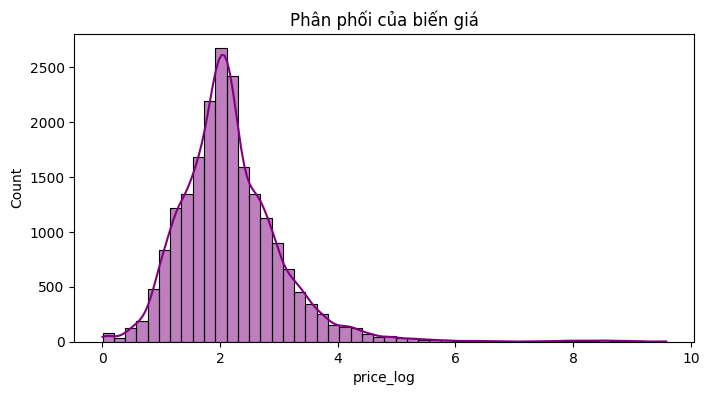

+ Skew: 1.6752320914169987
Kurtosis: 8.156472661251355


In [17]:
plt.figure(figsize=(8,4))
sns.histplot(df['price_log'], bins=50, kde=True, color="purple")
plt.title("Phân phối của biến giá")
plt.show()

print("+ Skew:", skew(df['price_log']))
print("Kurtosis:", kurtosis(df['price_log']))

Dữ liệu lệch phải nhưng không quá mạnh như dữ liệu gốc

In [18]:
df['area_log'].describe()

,area_log
count,20694.000000
mean,4.293015
std,0.632886
min,0.693147
25%,3.928388
50%,4.234107
75%,4.590716
max,11.849405


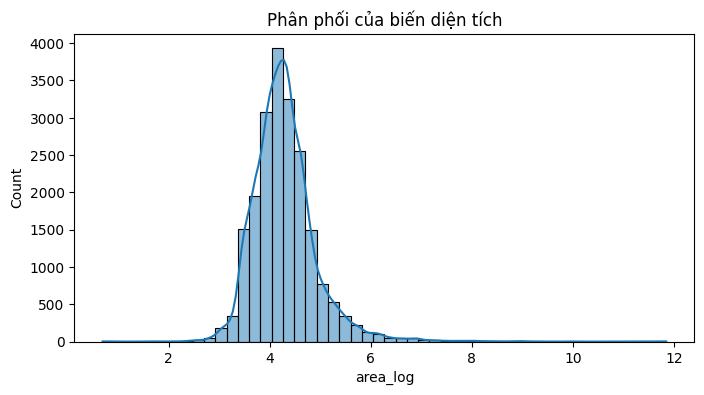

Skew: 1.66439511843183
Kurtosis: 8.867963859770379


In [19]:
plt.figure(figsize=(8,4))
sns.histplot(df['area_log'], bins=50, kde=True)
plt.title("Phân phối của biến diện tích")
plt.show()

print("Skew:", skew(df['area_log']))
print("Kurtosis:", kurtosis(df['area_log']))

cần chuẩn hóa dùng RobustScaler tránh được sự ảnh hưởng của outlier

**Tổng kết:**

- Target: price_log không xử lý

- Ordinal: bedroom_group, title_length -> dùng OrdinalEncoder

- Nominal: location -> dùng OneHotEncoder

- Biến area_log dùng RobustScaler để chuẩn hóa tránh các outlier

In [20]:
# Ordinal (có thứ tự)
ordinal_cols = ['bedroom_group', 'title_length']

# Nominal (không thứ tự)
nominal_cols = ['location']

# Numeric cần scale (có outlier)
# robust_scale_cols = ['area_log']

# Numeric không scale
passthrough_cols = [
    'is_legal',
    'quarter',
    'is_center'
]

# Tách biến độc lập và phụ thuộc
X = df[ordinal_cols + nominal_cols + passthrough_cols]
y = df['price_log']

# Thiết lập Ordinal Encoder
ordinal_encoder = OrdinalEncoder(
    categories=[
        ['nhỏ', 'vừa', 'lớn'],                 # bedroom_group
        ['ngắn', 'vừa', 'dài']                  # title_length
    ]
)

# Thiết lập One Hot Encoder
onehot_encoder = OneHotEncoder(
    drop='first',
    handle_unknown='ignore'
)

# Thiết lập Column Transformer cho pipeline xử lý
preprocessor = ColumnTransformer(
    transformers=[
        # ('robust', RobustScaler(), robust_scale_cols),
        ('pass', 'passthrough', passthrough_cols),
        ('ord', ordinal_encoder, ordinal_cols),
        ('nom', onehot_encoder, nominal_cols)
    ]
)

# 4. Chia dữ liệu, thiết lập mô hình và tiến hành huấn luyện

Sử dụng các mô hình:

- Linear Regression

- SVM

- Decision Tree

- Random Forest

- Catboost

- LightGMB

- Xgboost

In [21]:
# Thiết lập các mô hình
# Linear Regression
lr = LinearRegression()

# SVM
svm = SVR(kernel='rbf', C=10, epsilon=0.1)

# Decision Tree
dt = DecisionTreeRegressor(
            max_depth=10,
            random_state=42
        )

# Random Forest
rf = RandomForestRegressor(
            n_estimators=300,
            max_depth=15,
            random_state=42,
            n_jobs=-1
        )

# XGBoost
xgb = XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        )

# LightGBM
lgbm = LGBMRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=-1,
            random_state=42
        )


# CatBoost
cb = CatBoostRegressor(
            iterations=300,
            learning_rate=0.05,
            depth=6,
            verbose=0,
            random_state=42
        )

models = {
    "Linear Regression": lr,
    "SVM": svm,
    "Decision Tree": dt,
    "Random Forest": rf,
    "XGBoost": xgb,
    "LightGBM": lgbm,
    "CatBoost": cb
}

In [24]:
def get_feature_names(pipeline):
    return pipeline.named_steps['preprocess'].get_feature_names_out()


def train_model(X, y, model, model_name):
    print(f"\n========== {model_name} ==========")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    pipeline = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # =============================
    # METRICS
    # =============================
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    print("R2:", r2)
    print("RMSE:", rmse)
    print("MAE:", mae)

    feature_names = get_feature_names(pipeline)

    # =============================
    # LINEAR MODELS
    # =============================
    if hasattr(pipeline.named_steps['model'], 'coef_'):
        coef = pipeline.named_steps['model'].coef_

        coef_df = pd.DataFrame({
            'feature': feature_names,
            'coefficient': coef,
            'abs_coef': np.abs(coef)
        }).sort_values(by='abs_coef', ascending=False)

        print("\nTop 10 coefficients:")
        print(coef_df.head(10))

    # =============================
    # TREE / ENSEMBLE MODELS
    # =============================
    elif hasattr(pipeline.named_steps['model'], 'feature_importances_'):
        importances = pipeline.named_steps['model'].feature_importances_

        imp_df = pd.DataFrame({
            'feature': feature_names,
            'importance': importances
        }).sort_values(by='importance', ascending=False)

        print("\nTop 10 feature importances:")
        print(imp_df.head(10))

    # =============================
    # SVM / MODEL KHÔNG CÓ IMPORTANCE
    # =============================
    else:
        print("\nModel không có feature importance trực tiếp → dùng Permutation Importance")

        X_test_transformed = pipeline.named_steps['preprocess'].transform(X_test)

        r = permutation_importance(
            pipeline.named_steps['model'],
            X_test_transformed,
            y_test,
            n_repeats=10,
            random_state=42,
            scoring='r2'
        )

        perm_df = pd.DataFrame({
            'feature': feature_names,
            'importance': r.importances_mean
        }).sort_values(by='importance', ascending=False)

        print("\nTop 10 permutation importances:")
        print(perm_df.head(10))

    # =============================
    # RETURN KẾT QUẢ
    # =============================
    return {
        "model": model_name,
        "pipeline": pipeline,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae
    }


# 5. Huấn luyện mô hình

In [25]:
results = []

for name, model in models.items():
    res = train_model(X, y, model, name)
    results.append(res)

result_df = pd.DataFrame(results)[["model", "RMSE", "MAE", "R2"]]
result_df


========== Linear Regression ==========
R2: 0.2509234449169755
RMSE: 0.7970078507324122
MAE: 0.5211075502582246

Top 10 coefficients:
                     feature  coefficient  abs_coef
3         ord__bedroom_group     0.588230  0.588230
6         nom__location_Khác    -0.522298  0.522298
2            pass__is_center     0.295169  0.295169
5  nom__location_Hồ Chí Minh    -0.133649  0.133649
4          ord__title_length     0.058062  0.058062
0             pass__is_legal     0.034546  0.034546
1              pass__quarter     0.018313  0.018313

========== SVM ==========
R2: 0.24361268404328806
RMSE: 0.8008876851343665
MAE: 0.5008987575007909

Model không có feature importance trực tiếp → dùng Permutation Importance

Top 10 permutation importances:
                     feature  importance
3         ord__bedroom_group    0.297183
6         nom__location_Khác    0.076714
2            pass__is_center    0.045680
1              pass__quarter    0.017052
5  nom__location_Hồ Chí Minh    0.01

,model,RMSE,MAE,R2
0,Linear Regression,0.797008,0.521108,0.250923
1,SVM,0.800888,0.500899,0.243613
2,Decision Tree,0.796096,0.516509,0.252636
3,Random Forest,0.795844,0.516339,0.253110
4,XGBoost,0.794427,0.515329,0.255767
5,LightGBM,0.794238,0.515469,0.256121
6,CatBoost,0.793206,0.514662,0.258053


# 6. Đánh giá mô hình

In [26]:
def plot_model_comparison(results_df):
    """
    Vẽ biểu đồ so sánh các mô hình dựa trên RMSE, MAE và R2

    Parameters
    ----------
    results_df : pd.DataFrame
        DataFrame chứa các cột:
        ['model', 'RMSE', 'MAE', 'R2']
    """

    metrics = ["RMSE", "MAE", "R2"]

    for metric in metrics:
        plt.figure(figsize=(10, 5))
        plt.bar(results_df["model"], results_df[metric])
        plt.title(f"Model Comparison - {metric}")
        plt.xlabel("Model")
        plt.ylabel(metric)
        plt.xticks(rotation=30, ha="right")
        plt.grid(axis="y", linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()